# **Daily Seasonal Adjustment (DSA)**
Antes de ejecutar, **es importante completar/modificar todas las secciones marcadas con [TBC]**:
* (2) Lectura de datos > Subida manual de CSV: ruta del fichero de entrada (`INPUT_PATH`).
* (3) Procesamiento del dato > Dummies (ad-hoc).
* (4) Modelización > Hiperparámetros DSA (`TARGET_COL`, `FORECAST_HORIZON`, etc.).
* (5) Guardado: ruta del fichero de salida (`OUTPUT_PATH`).

## (1) Instalación y lectura de paquetes

In [1]:
system("apt-get update -qq")
system("apt-get install -y default-jdk r-cran-rjava")

system("R CMD javareconf")

install.packages(c(
  "dsa",
  "xts",
  "zoo",
  "lubridate",
  "dplyr",
  "openxlsx",
  "timeDate",
  "ggplot2"
), repos = "https://cloud.r-project.org")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘RcppArmadillo’, ‘plyr’, ‘R2HTML’, ‘tsoutliers’, ‘forecast’, ‘dygraphs’, ‘gridExtra’, ‘reshape2’, ‘seastests’




In [2]:
rm(list = ls())
Sys.setenv(TZ = "Europe/Madrid")

library(dplyr)
library(xts)
library(lubridate)
library(dsa)
library(openxlsx)
library(timeDate)
library(ggplot2)
library(timeDate) # Para la función Easter()


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from 

## (2) Lectura del dato [**TBC**]

### Subida manual de CSV [**TBC**]

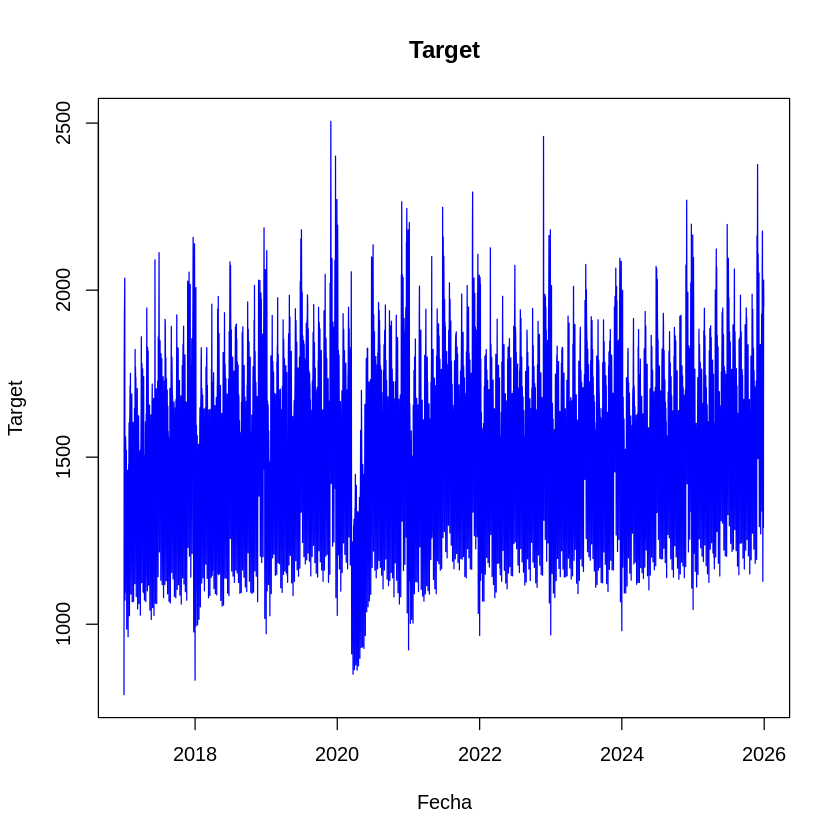

In [4]:
# ============================================================
# Manual
# ============================================================
# Definir la ruta
INPUT_PATH <- "Data - Consumo_BD.csv"

# Leer el archivo
Data <- read.csv(
  INPUT_PATH,
  skip = 2,
  header = TRUE,
  dec = ",",
  stringsAsFactors = FALSE
)

# Parsear las columnas
Data$timestamp <- as.Date(Data$timestamp, format = "%d/%m/%Y")
Data$target <- as.numeric(Data$target)
Data <- Data[, c("timestamp", "target")]

# Crear un pequeño plot de la evolución del target
plot(Data$timestamp, Data$target,
     type = "l",
     col = "blue",
     main = "Target",
     xlab = "Fecha",
     ylab = "Target")

### Conexión a Google Sheets (Acceso bloqueado para cuenta BBVA)

In [ ]:
# ============================================================
# Google Sheets (acceso bloqueado a usuario BBVA)
# ============================================================
#FILE_ID <- "1hakzOf9fUA8dA9TLxeph4wrd3EpWUWS0jI8QbzfGBsg"
#SHEET <- "Consumo_BD"

# Autenticación interactiva (en Colab se abrirá un enlace para autenticar)
#gs4_auth()
#Data <- read_sheet(ss = FILE_ID, sheet = SHEET)

## (3) Procesamiento del dato [**TBC**]

### Semana (5 o 7 días) [**TBC**]

In [5]:
# ============================================================
# Full week or labor week
# ============================================================

### TBC: Choose between 5 or 7
# 5 = solo lunes-viernes; 7 = calendario completo.
SERIES_WEEK_DAYS <- 7

keep_calendar_days <- function(df, date_col = "timestamp", week_days = SERIES_WEEK_DAYS) {
  df[[date_col]] <- as.Date(df[[date_col]])
  df
}

Data <- keep_calendar_days(Data, "timestamp", SERIES_WEEK_DAYS)

### Transformación (nivel o log o log1p) [**TBC**]

In [6]:
# ============================================================
# Transformation
# ============================================================

### TBC: Choose between "level" / "log" / "log1p"
TRANSFORMATION <- "log"

# Funciones de transformación y reversión
transform_level <- function(x, transformation = c("log", "log1p", "level")) {
  transformation <- match.arg(transformation)

  if (transformation == "log") {
    return(log(x))
  }

  if (transformation == "log1p") {
    return(log1p(x))
  }

  if (transformation == "level") {
    return(x)
  }
}

inverse_transform <- function(x, transformation = c("log", "log1p", "level")) {
  transformation <- match.arg(transformation)

  if (transformation == "log") {
    return(exp(x))
  }

  if (transformation == "log1p") {
    return(expm1(x))
  }

  if (transformation == "level") {
    return(x)
  }
}

# Aplicar transformación
Data$target_proc <- transform_level(Data$target, TRANSFORMATION)

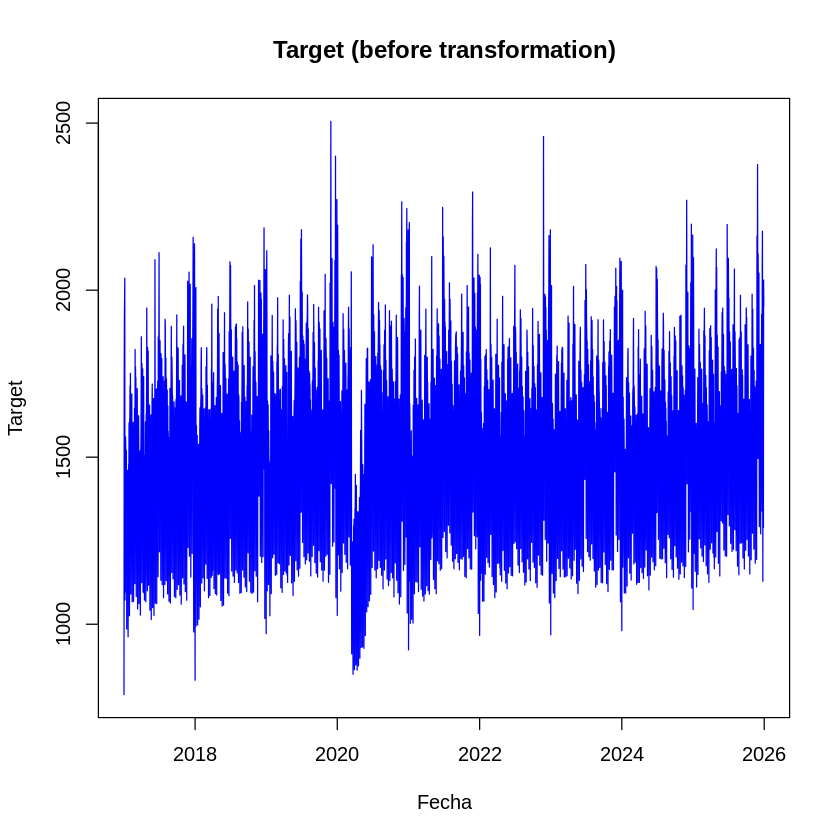

In [7]:
# Plot original series
plot(Data$timestamp, Data$target,
     type = "l",
     col = "blue",
     main = "Target (before transformation)",
     xlab = "Fecha",
     ylab = "Target")

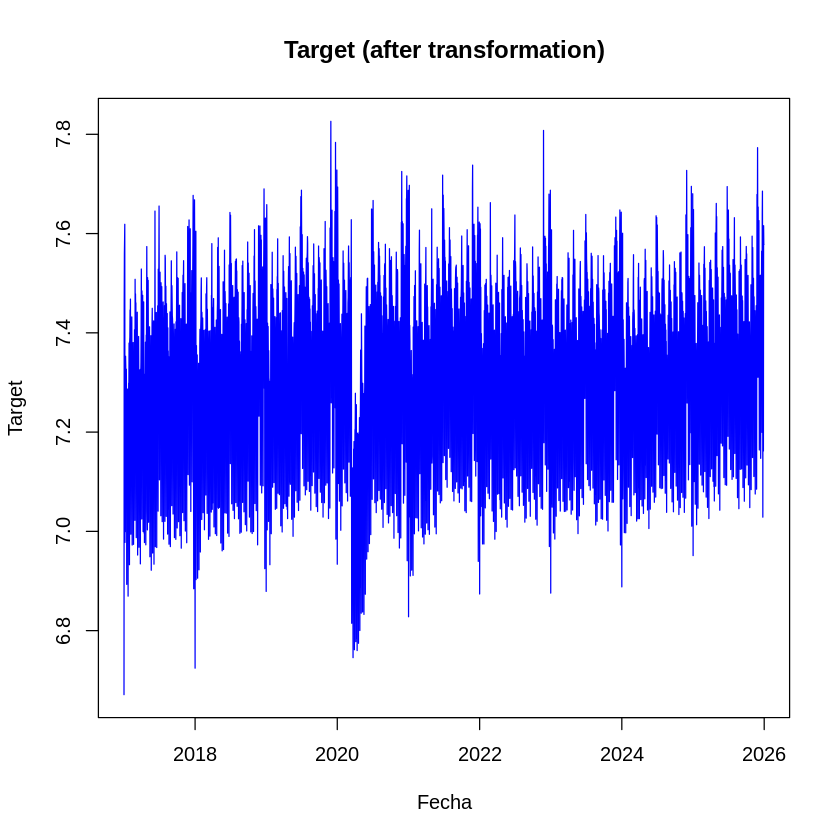

In [8]:
# Plot resulting series
Data$target_proc <- as.numeric(Data$target_proc)
plot(Data$timestamp, Data$target_proc,
     type = "l",
     col = "blue",
     main = "Target (after transformation)",
     xlab = "Fecha",
     ylab = "Target")

### Dummies [**TBC**]

In [9]:
# ============================================================
# Calendar covariates y calendario de la serie
# ============================================================

add_calendar_covariates <- function(df, date_col = "timestamp") {
  df <- df %>%
    mutate(
      timestamp = as.Date(.data[[date_col]]),
      dow = wday(timestamp, week_start = 1) - 1,
      month = month(timestamp),
      day = day(timestamp),
      week = isoweek(timestamp),
      is_weekend = as.integer(dow >= 5)
    )

  years <- unique(year(df$timestamp))

  fixed_holidays <- do.call(c, lapply(years, function(y) {
    as.Date(c(
      paste0(y, "-01-01"), paste0(y, "-01-06"), paste0(y, "-05-01"),
      paste0(y, "-05-02"), paste0(y, "-06-24"), paste0(y, "-08-15"),
      paste0(y, "-10-12"), paste0(y, "-11-01"), paste0(y, "-12-06"),
      paste0(y, "-12-08"), paste0(y, "-12-25"), paste0(y, "-12-31")
    ))
  }))

  easter_sundays <- as.Date(Easter(years))
  easter_related <- do.call(c, lapply(easter_sundays, function(e) {
    as.Date(e + days(-7:1))
  }))

  holidays_all <- unique(c(fixed_holidays, easter_related))

  df <- df %>%
    mutate(
      is_holiday = as.integer(timestamp %in% holidays_all),
      is_pre_holiday = as.integer((timestamp + days(1)) %in% holidays_all),
      is_post_holiday = as.integer((timestamp - days(1)) %in% holidays_all),
      is_bridge_day = as.integer(
        (is_weekend == 0 & is_holiday == 0) & (is_pre_holiday == 1 | is_post_holiday == 1)
      ),
      is_easter_week = as.integer(timestamp %in% easter_related)
    )

  return(df)
}

# Añadir covariates
Data <- add_calendar_covariates(Data, "timestamp")
head(Data)

,timestamp,target,target_proc,dow,month,day,week,is_weekend,is_holiday,is_pre_holiday,is_post_holiday,is_bridge_day,is_easter_week
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
1,2017-01-01,789.172,6.670984,6,1,1,52,1,1,0,0,0,0
2,2017-01-02,1731.510,7.456749,0,1,2,1,0,0,0,1,1,0
3,2017-01-03,1919.130,7.559627,1,1,3,1,0,0,0,0,0,0
4,2017-01-04,1972.950,7.587285,2,1,4,1,0,0,0,0,0,0
5,2017-01-05,2035.940,7.618713,3,1,5,1,0,0,1,0,1,0
6,2017-01-06,1072.560,6.977804,4,1,6,1,0,1,0,0,0,0


In [10]:
safe_log_scalar <- function(x) {
  if (length(x) == 0 || is.na(x) || !is.finite(x) || x <= 0) {
    return(NA_real_)
  }
  log(x)
}

aggregate_level <- function(x, agg = "sum", empty_value = NA_real_) {
  x <- as.numeric(x)
  x <- x[is.finite(x)]

  if (length(x) == 0) {
    return(empty_value)
  }

  if (agg == "sum") {
    return(sum(x))
  }

  if (agg == "mean") {
    return(mean(x))
  }

  stop("agg debe ser 'sum' o 'mean'.")
}

### Conversión a serie temporal

In [11]:
# ============================================================
# Convert to xts
# ============================================================
Data <- Data %>% arrange(timestamp)
Data_ts <- xts(x = Data[, -1], order.by = Data$timestamp)
Data_ts <- na.omit(Data_ts)
Data <- na.omit(Data)

## (4) DSA [**TBC**]

Some hyperarameters...
* `model`: Allows specifying the ARIMA order (e.g., \(c(3,1,0)\)) for the non-seasonal part.
* `fourier_number`: Determines the number of trigonometric regressors used to model annual and monthly seasonality.
* `s.window`: Specifies the STL parameter for seasonality smoothing, allowing the seasonal pattern to change over time.
* `outlier`: Whether the algorithm includes automatic outlier adjustment or not.

See the full hyperparam documentation [here](https://danielollech.r-universe.dev/dsa/doc/manual.html).

### (4.A) Predicción univariable **estática**

In [ ]:
TARGET_COLUMN <- "target_proc"
FORECAST_HORIZON <- 30

  |======================================================================| 100%
         MAE       RMSE      MAPE     sMAPE        R2
1 0.06795459 0.07949971 0.9192042 0.9186001 0.7712174


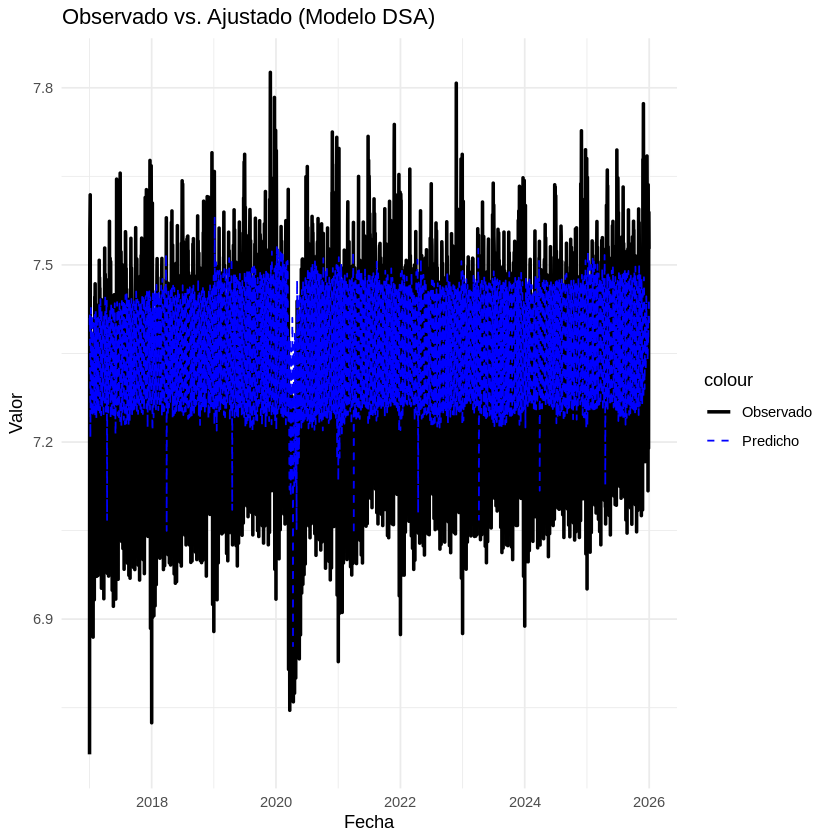

In [ ]:
# ============================================================
# DSA Model - Dentro de Muestra
# ============================================================
calendar_regressors <- setdiff(colnames(Data_ts), TARGET_COLUMN)

regressors <- index(Data_ts)[1:(nrow(Data_ts) - FORECAST_HORIZON)]
regressors_future <- index(Data_ts)[(nrow(Data_ts) - FORECAST_HORIZON + 1):nrow(Data_ts)]

model_list <- list()
results_list <- list()

reg <- multi_xts2ts(
  Data_ts[regressors, calendar_regressors],
  short = TRUE
)

regf <- multi_xts2ts(
  Data_ts[regressors_future, calendar_regressors],
  short = TRUE
)

model_list[[TARGET_COLUMN]] <- dsa(
  Data_ts[regressors, TARGET_COLUMN],
  regressor = reg,
  forecast_regressor = regf,
  h = FORECAST_HORIZON,
  automodel = 'full',
  ic = 'bic',
  include.constant = TRUE
)

results_list[[TARGET_COLUMN]] <- data.frame(
  date = index(model_list[[TARGET_COLUMN]]$output$original),
  original = as.numeric(model_list[[TARGET_COLUMN]]$output$original),
  seas_adj = as.numeric(model_list[[TARGET_COLUMN]]$output$seas_adj),
  trend = as.numeric(model_list[[TARGET_COLUMN]]$output$trend),
  sc_fac = as.numeric(model_list[[TARGET_COLUMN]]$output$sc_fac)
)

# Función para métricas
calculate_metrics <- function(actual, predicted) {
  mae  <- mean(abs(actual - predicted), na.rm = TRUE)
  rmse <- sqrt(mean((actual - predicted)^2, na.rm = TRUE))
  mape <- mean(abs((actual - predicted) / actual), na.rm = TRUE) * 100
  smape <- mean(2 * abs(actual - predicted) / (abs(actual) + abs(predicted)), na.rm = TRUE) * 100
  rss <- sum((actual - predicted)^2, na.rm = TRUE)
  tss <- sum((actual - mean(actual, na.rm = TRUE))^2, na.rm = TRUE)
  r2  <- 1 - (rss / tss)
  return(data.frame(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, R2=r2))
}

# Extraer datos
res <- results_list[[TARGET_COLUMN]]
actual_vals <- as.numeric(res$original)
pred_vals <- as.numeric(res$trend) + as.numeric(res$sc_fac) # Tendencia + Factores Estacionales y de Calendario
metrics <- calculate_metrics(actual_vals, pred_vals)
print(metrics)

# Plot
ggplot(res, aes(x = date)) +
  geom_line(aes(y = original, color = "Observado"), linewidth = 1) +
  geom_line(aes(y = seas_adj, color = "Predicho"), linetype = "dashed") +
  labs(title = "Observado vs. Ajustado (Modelo DSA)", y = "Valor", x = "Fecha") +
  theme_minimal() +
  scale_color_manual(values = c("Observado" = "black", "Predicho" = "blue"))

  |======================================================================| 100%
[1] "--- MÉTRICAS DE FORECAST EN EL PERIODO TEST (FUTURO) ---"
         MAE       RMSE     MAPE     sMAPE        R2
1 0.05833455 0.07202522 0.780373 0.7791907 0.8029672


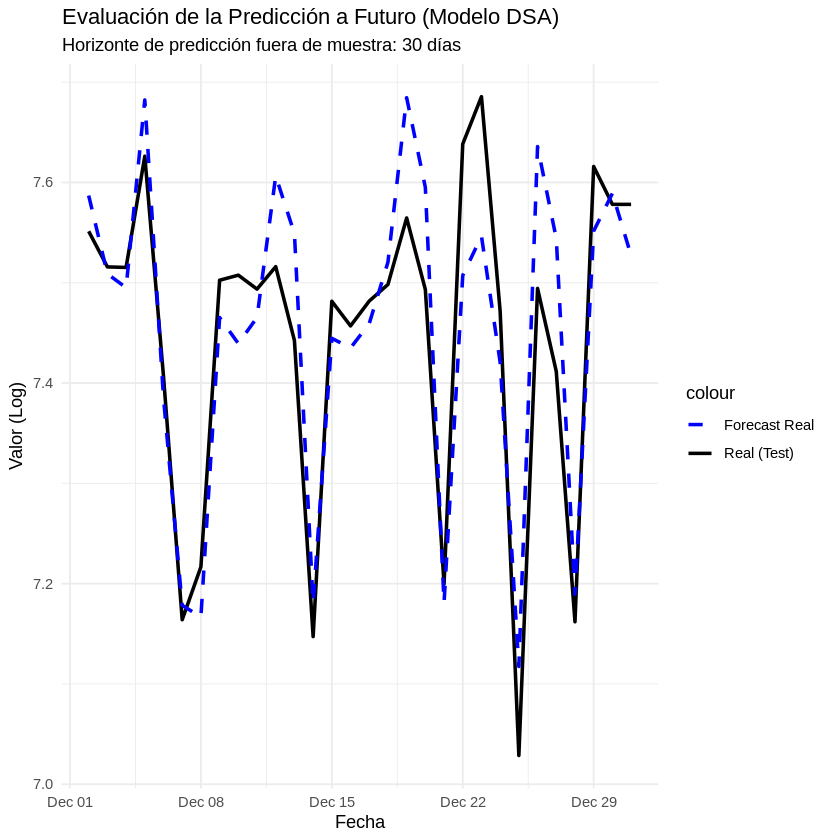

In [ ]:
# ============================================================
# DSA Model - Fuera de Muestra
# ============================================================
calendar_regressors <- setdiff(colnames(Data_ts), TARGET_COLUMN)

# Separación de índices temporales (Train vs Test)
regressors <- index(Data_ts)[1:(nrow(Data_ts) - FORECAST_HORIZON)]
regressors_future <- index(Data_ts)[(nrow(Data_ts) - FORECAST_HORIZON + 1):nrow(Data_ts)]

model_list <- list()

reg <- multi_xts2ts(
  Data_ts[regressors, calendar_regressors, drop = FALSE],
  short = TRUE
)

regf <- multi_xts2ts(
  Data_ts[regressors_future, calendar_regressors, drop = FALSE],
  short = TRUE
)

# Entrenamos solo con el periodo de regresores (Train)
model_list[[TARGET_COLUMN]] <- dsa(
  Data_ts[regressors, TARGET_COLUMN],
  regressor = reg,
  forecast_regressor = regf,
  h = FORECAST_HORIZON,
  automodel = 'full',
  ic = 'bic',
  include.constant = TRUE
)

# ============================================================
# EXTRACCIÓN DEL PERIOD TEST (FUTURO)
# ============================================================

# 1. Extraemos la serie proyectada completa (Pasado + Horizonte Futuro)
full_series_forecast <- get_original(model_list[[TARGET_COLUMN]], forecast = TRUE)

# 2. Cortamos estrictamente los últimos 'FORECAST_HORIZON' días para el Test
pred_vals   <- as.numeric(tail(full_series_forecast, FORECAST_HORIZON))
actual_vals <- as.numeric(Data_ts[regressors_future, TARGET_COLUMN])

# 3. Creamos un dataframe limpio exclusivo para el gráfico y control del Test
res_test <- data.frame(
  date     = regressors_future,
  real     = actual_vals,
  forecast = pred_vals
)

# ============================================================
# Cálculo de Métricas (Ajuste a Futuro Real)
# ============================================================
calculate_metrics <- function(actual, predicted) {
  mae  <- mean(abs(actual - predicted), na.rm = TRUE)
  rmse <- sqrt(mean((actual - predicted)^2, na.rm = TRUE))
  mape <- mean(abs((actual - predicted) / actual), na.rm = TRUE) * 100
  smape <- mean(2 * abs(actual - predicted) / (abs(actual) + abs(predicted)), na.rm = TRUE) * 100
  rss <- sum((actual - predicted)^2, na.rm = TRUE)
  tss <- sum((actual - mean(actual, na.rm = TRUE))^2, na.rm = TRUE)
  r2  <- 1 - (rss / tss)
  return(data.frame(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, R2=r2))
}

metrics <- calculate_metrics(res_test$real, res_test$forecast)
print("--- MÉTRICAS DE FORECAST EN EL PERIODO TEST (FUTURO) ---")
print(metrics)

# ============================================================
# Gráfico del Periodo de Forecast (Test)
# ============================================================
ggplot(res_test, aes(x = date)) +
  geom_line(aes(y = real, color = "Real (Test)"), linewidth = 1) +
  geom_line(aes(y = forecast, color = "Forecast Real"), linetype = "dashed", linewidth = 1) +
  labs(
    title = "Evaluación de la Predicción a Futuro (Modelo DSA)",
    subtitle = paste("Horizonte de predicción fuera de muestra:", FORECAST_HORIZON, "días"),
    y = "Valor",
    x = "Fecha"
  ) +
  theme_minimal() +
  scale_color_manual(values = c("Real (Test)" = "black", "Forecast Real" = "blue"))

### (4.B) Predicción univariable **en vendimias** [**TBC**]

#### Prueba básica

In [ ]:
# Configuración
TARGET_COLUMN <- "target_proc"
FORECAST_HORIZON <- 90
SKIP_STEPS <- 30 # Cada cuántos días hacemos un nuevo corte
WINDOWS <- 3 # Cuántas vendimias queremos probar

  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
[1] "--- MÉTRICAS EN DIARIO (LOGS) ---"
         MAE       RMSE      MAPE     sMAPE        R2   window
1 0.02940866 0.03872376 0.3993136 0.3989318 0.9231979 Window 1
2 0.03150061 0.04559224 0.4302772 0.4311847 0.8881201 Window 2
3 0.03676550 0.04760517 0.4986943 0.4984833 0.8932598 Window 3
4 0.04725943 0.06016918 0.6379638 0.6366455 0.8523103 Window 4
5 0.03623355 0.04802259 0.4915622 0.4913113 0.8892220     Mean


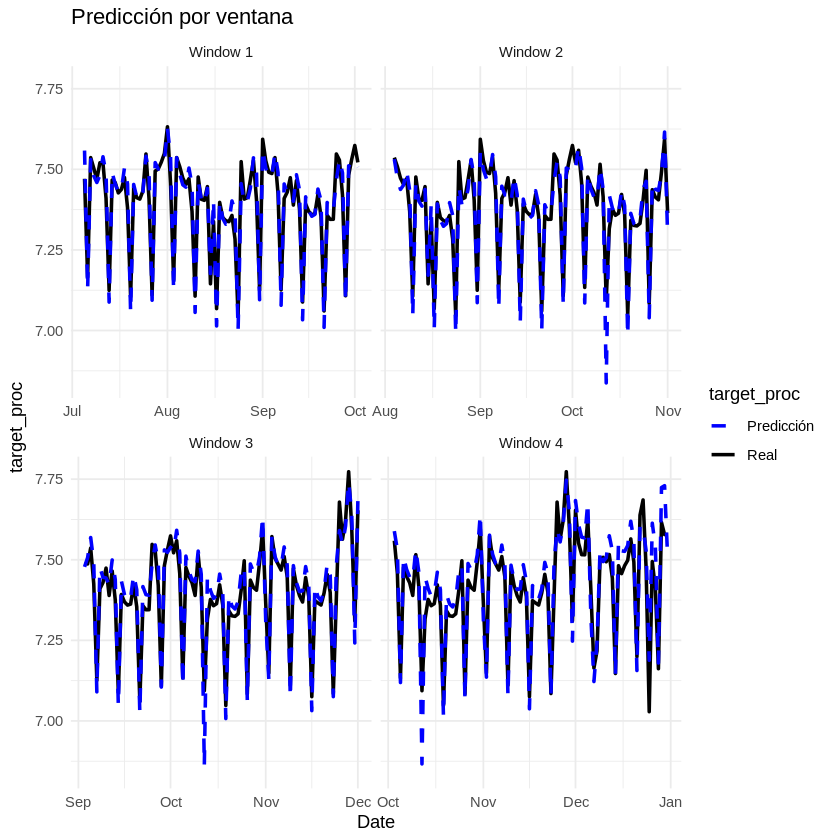

In [ ]:
# ============================================================
# Estimación Diaria
# (Predicción en logs > Métricas en logs)
# ============================================================

calendar_regressors <- setdiff(colnames(Data_ts), TARGET_COLUMN)

windows <- seq(
  nrow(Data_ts) - (WINDOWS * SKIP_STEPS) - FORECAST_HORIZON,
  nrow(Data_ts) - FORECAST_HORIZON,
  by = SKIP_STEPS
)

window_results <- list()
window_metrics <- data.frame()

for (i in seq_along(windows)) {

  skip_idx <- windows[i]

  full_train <- Data_ts[1:skip_idx, ]
  full_test  <- Data_ts[(skip_idx + 1):(skip_idx + FORECAST_HORIZON), ]

  y_train <- full_train[, TARGET_COLUMN]
  y_test  <- full_test[, TARGET_COLUMN]

  reg_train_xts <- full_train[, calendar_regressors]
  reg_test_xts  <- full_test[, calendar_regressors]

  reg_train <- multi_xts2ts(cbind(reg_train_xts))
  reg_test  <- multi_xts2ts(cbind(reg_test_xts), short = TRUE)

  valid_cols <- apply(reg_train, 2, var) > 0
  reg_train <- reg_train[, valid_cols]
  reg_test  <- reg_test[, valid_cols]

  fit <- dsa(
    y_train,
    regressor = reg_train,
    forecast_regressor = reg_test,
    h = FORECAST_HORIZON,
    automodel = 'reduced',
    ic = 'bic',
    include.constant = TRUE
  )

  # Extraemos la serie proyectada completa
  full_forecast <- get_original(fit, forecast = TRUE)

  # Extraemos únicamente los pasos futuros correspondientes al forecast real
  pred <- as.numeric(tail(full_forecast, FORECAST_HORIZON))
  real <- as.numeric(y_test)

  window_results[[i]] <- data.frame(
    fecha = index(y_test),
    pred = pred,
    real = real,
    window = paste("Window", i)
  )

  m <- calculate_metrics(real, pred)
  m$window = paste("Window", i)
  window_metrics <- rbind(window_metrics, m)
}

# Tabla de métricas
met_num <- window_metrics[, sapply(window_metrics, is.numeric), drop = FALSE]
promedios <- colMeans(met_num, na.rm = TRUE)
mean_row <- as.data.frame(t(promedios))
mean_row$window <- "Mean"
window_metrics <- rbind(window_metrics, mean_row)
print("--- MÉTRICAS EN DIARIO (LOGS) ---")
print(window_metrics)

# Gráfico
df_plot <- do.call(rbind, window_results)
ggplot(df_plot, aes(x = fecha)) +
  geom_line(aes(y = real, color = "Real"), linewidth = 1) +
  geom_line(aes(y = pred, color = "Predicción"), linetype = "dashed", linewidth = 1) +
  facet_wrap(~window, scales = "free_x") + # Modificado a free_x para mantener escalas verticales comparables si se desea
  theme_minimal() +
  labs(title = "Predicción por ventana", color = TARGET_COLUMN, y = TARGET_COLUMN, x = "Date") +
  scale_color_manual(values = c("Real" = "black", "Predicción" = "blue"))

[1] "--- MÉTRICAS EN AGREGACIÓN SEMANAL (LOGS) ---"
          MAE        RMSE       MAPE      sMAPE        R2        window
1 0.009772375 0.012839416 0.10979532 0.10971336 0.9986780      Window 1
2 0.007245930 0.009693512 0.07757505 0.07760382 0.9695526      Window 2
3 0.019704601 0.021595680 0.21645919 0.21618433 0.9976120      Window 3
4 0.030231096 0.034312857 0.32982490 0.32911655 0.9849758      Window 4
5 0.016738500 0.019610366 0.18341362 0.18315452 0.9877046 Mean (Weekly)


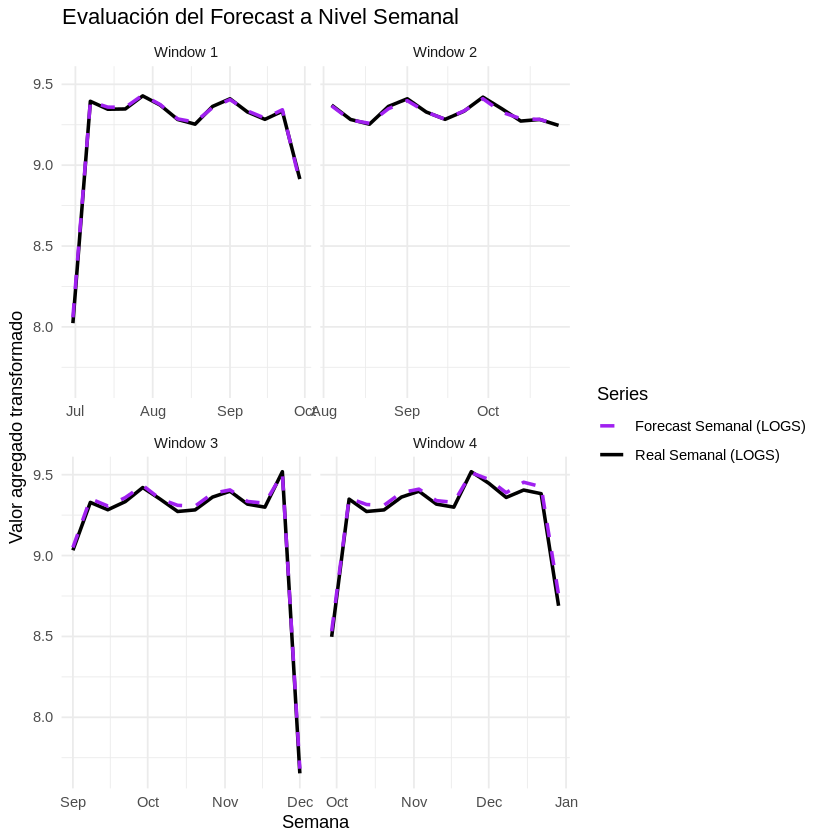

In [ ]:
# ============================================================
# Estimación Semanal
# (Tomar predicción diaria en logs > Convertir a niveles > Agregar en Semanas > Transformar a logs > Métricas en logs)
# ============================================================

# Revertimos los resultados diarios a NIVELES
df_daily_results <- do.call(rbind, window_results) %>%
  mutate(
    fecha = as.Date(fecha),
    # Volver de escala procesada diaria a niveles diarios
    real_level = inverse_transform(real, TRANSFORMATION),
    pred_level = inverse_transform(pred, TRANSFORMATION)
  )

# Agregación semanal en NIVELES y posterior transformación semanal a LOGS
df_weekly_metrics <- df_daily_results %>%
  mutate(
    semana = floor_date(fecha, unit = "week", week_start = 1)
  ) %>%
  group_by(window, semana) %>%
  summarise(
    real_weekly_level = sum(real_level, na.rm = TRUE),
    pred_weekly_level = sum(pred_level, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    # Transformación de vuelta a LOGS
    real_weekly_proc = transform_level(real_weekly_level, TRANSFORMATION),
    pred_weekly_proc = transform_level(pred_weekly_level, TRANSFORMATION)
  )
weekly_metrics_table <- data.frame()
for (w in unique(df_weekly_metrics$window)) {
  sub_df <- filter(df_weekly_metrics, window == w)
  m_weekly <- calculate_metrics(
    sub_df$real_weekly_proc,
    sub_df$pred_weekly_proc
  )
  m_weekly$window <- w
  weekly_metrics_table <- rbind(weekly_metrics_table, m_weekly)
}
met_num_w <- weekly_metrics_table[, sapply(weekly_metrics_table, is.numeric), drop = FALSE]
mean_row_w <- as.data.frame(t(colMeans(met_num_w, na.rm = TRUE)))
mean_row_w$window <- "Mean (Weekly)"
weekly_metrics_table <- rbind(weekly_metrics_table, mean_row_w)

print("--- MÉTRICAS EN AGREGACIÓN SEMANAL (LOGS) ---")
print(weekly_metrics_table)

# Gráfico semanal
ggplot(df_weekly_metrics, aes(x = semana)) +
  geom_line(aes(y = real_weekly_proc, color = "Real Semanal (LOGS)"), linewidth = 1) +
  geom_line(aes(y = pred_weekly_proc, color = "Forecast Semanal (LOGS)"), linetype = "dashed", linewidth = 1) +
  facet_wrap(~window, scales = "free_x") +
  theme_minimal() +
  labs(
    title = "Evaluación del Forecast a Nivel Semanal",
    color = "Series",
    y = "Valor agregado transformado",
    x = "Semana"
  ) +
  scale_color_manual(
    values = c(
      "Real Semanal (LOGS)" = "black",
      "Forecast Semanal (LOGS)" = "purple"
    )
  )

[1] "--- MÉTRICAS EN AGREGACIÓN MENSUAL (LOGS) ---"
          MAE        RMSE       MAPE      sMAPE          R2         window
1 0.004268343 0.004274795 0.03949100 0.03948318   0.2237303       Window 1
2 0.001668136 0.002075503 0.01543665 0.01543849   0.9689842       Window 2
3 0.014151589 0.016464624 0.13069684 0.13058134 -48.4543617       Window 3
4 0.025267821 0.029095666 0.23210569 0.23174982   0.3065577       Window 4
5 0.011338972 0.012977647 0.10443255 0.10431321 -11.7387724 Mean (Monthly)


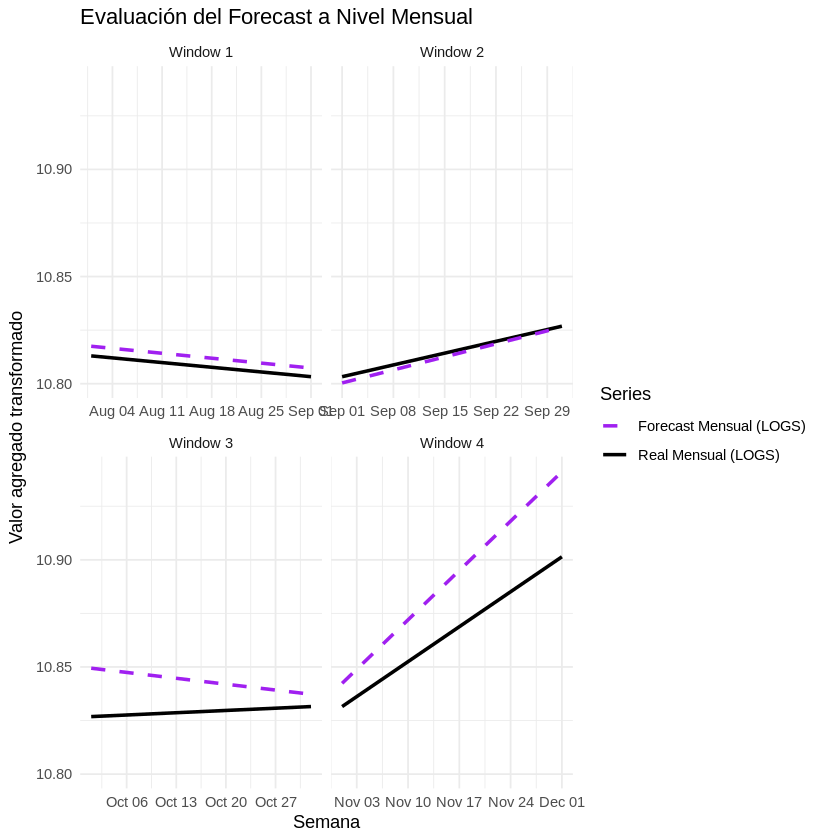

In [ ]:
# ============================================================
# Estimación mensual
# (Tomar predicción diaria en logs > Convertir a niveles > Agregar en Meses > Transformar a logs > Métricas en logs)
# ============================================================

df_monthly_metrics <- df_daily_results %>%
  mutate(
    mes = floor_date(fecha, unit = "month"),
    month_end = ceiling_date(mes, unit = "month") - days(1)  # Filtramos los meses incompletos
  ) %>%
  group_by(window, mes, month_end) %>%
  filter(
    min(fecha) == mes,
    max(fecha) == month_end
  ) %>%
  summarise(
    real_monthly_level = sum(real_level, na.rm = TRUE),
    pred_monthly_level = sum(pred_level, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    real_monthly_proc = transform_level(real_monthly_level, TRANSFORMATION),
    pred_monthly_proc = transform_level(pred_monthly_level, TRANSFORMATION)
  )
monthly_metrics_table <- data.frame()
for (w in unique(df_monthly_metrics$window)) {
  sub_df <- filter(df_monthly_metrics, window == w)
  m_monthly <- calculate_metrics(
    sub_df$real_monthly_proc,
    sub_df$pred_monthly_proc
  )
  m_monthly$window <- w
  monthly_metrics_table <- rbind(monthly_metrics_table, m_monthly)
}
met_num_m <- monthly_metrics_table[, sapply(monthly_metrics_table, is.numeric), drop = FALSE]
mean_row_m <- as.data.frame(t(colMeans(met_num_m, na.rm = TRUE)))
mean_row_m$window <- "Mean (Monthly)"
monthly_metrics_table <- rbind(monthly_metrics_table, mean_row_m)
print("--- MÉTRICAS EN AGREGACIÓN MENSUAL (LOGS) ---")
print(monthly_metrics_table)

# Gráfico mensual
ggplot(df_monthly_metrics, aes(x = mes)) +
  geom_line(aes(y = real_monthly_proc, color = "Real Mensual (LOGS)"), linewidth = 1) +
  geom_line(aes(y = pred_monthly_proc, color = "Forecast Mensual (LOGS)"), linetype = "dashed", linewidth = 1) +
  facet_wrap(~window, scales = "free_x") +
  theme_minimal() +
  labs(
    title = "Evaluación del Forecast a Nivel Mensual",
    color = "Series",
    y = "Valor agregado transformado",
    x = "Semana"
  ) +
  scale_color_manual(
    values = c(
      "Real Mensual (LOGS)" = "black",
      "Forecast Mensual (LOGS)" = "purple"
    )
  )

#### Prueba completa [**TBC**]

El warning que aparece al ejecutar el modelo DSA surge por eliminar los 29s de febreros de años bisiestos.

In [ ]:
# ============================================================
# CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

TARGET_COLUMN <- "target_proc"  # Variable objetivo del modelo DSA
LEVEL_TARGET_COLUMN <- "target" # Serie original en niveles
DATE_COLUMN   <- "timestamp"   # Columna de fechas

TRAIN_HISTORY_START <- "2017-01-01" # Fecha inicial del hist?rico para entrenar
FORECAST_START_DATE <- "2022-01-01" # Cuándo empiezan a evaluarse los cortes (Enero 2022)
LAST_CUTOFF_DATE    <- "2025-12-21" # Último corte disponible

CUTOFF_DAYS      <- c(7, 14, 21)   # Cortes tras la 1a, 2a y 3a semana de cada mes
NEXT_FULL_MONTHS <- 3              # Cada ventana predice el resto del mes + 3 meses completos
AGGREGATE_FUN    <- "sum"          # Función de agregación de los datos diarios en semanales/mensuales
LEAP_YEARS       <- "add_to_28"    # "add_to_28" añade el valor del 29/02 al 28/02 / "drop" elimina el valor del 29/02

# Chronos2_calendar_vendimias_(Camilo).ipynb genera 144 ventanas con estos cortes
N_FORECAST_WINDOWS <- 144

In [ ]:
# ============================================================
# DEFINICIÓN DE FUNCIONES
# ============================================================

# Función de tratamiento de años bisiestos (29 de febreros)
handle_leap_days <- function(df,
                             date_col = DATE_COLUMN,
                             level_target_col = "target",
                             target_col = TARGET_COLUMN,
                             transformation = TRANSFORMATION,
                             method = c("drop", "add_to_28")) {

  method <- match.arg(method)
  df[[date_col]] <- as.Date(df[[date_col]])
  df <- df %>% arrange(.data[[date_col]])
  is_leap_day <- month(df[[date_col]]) == 2 & day(df[[date_col]]) == 29
  if (method == "add_to_28" && any(is_leap_day)) {
    leap_rows <- which(is_leap_day)
    for (i in leap_rows) {
      idx_28 <- which(df[[date_col]] == df[[date_col]][i] - days(1))
      if (length(idx_28) == 1) {
        df[[level_target_col]][idx_28] <-
          df[[level_target_col]][idx_28] + df[[level_target_col]][i]
      }
    }
  }
  df <- df %>%
    filter(!is_leap_day) %>%
    arrange(.data[[date_col]])
  df[[target_col]] <- transform_level(df[[level_target_col]], transformation)
  df
}

# Función para tratamiento de las semanas
date_sequence_by_week_days <- function(start_date, end_date, week_days = SERIES_WEEK_DAYS) {
  start_date <- as.Date(start_date)
  end_date   <- as.Date(end_date)
  if (is.na(start_date) || is.na(end_date) || start_date > end_date) {
    return(as.Date(character()))
  }
  idx <- seq(start_date, end_date, by = "1 day")
  if (week_days == 5) {
    idx <- idx[wday(idx, week_start = 1) <= 5]
  } else if (week_days != 7) {
    stop("week_days debe ser 5 (lunes-viernes) o 7 (calendario completo).")
  }
  as.Date(idx)
}

# Función de agregación de resultados diarios a semanal/mensual (Diario PROC > Diario niveles > Agregado niveles > Agregado PROC)
build_aggregate_eval <- function(daily_eval_df,
                                 context_df,
                                 date_col = DATE_COLUMN,
                                 level_target_col = LEVEL_TARGET_COLUMN,
                                 unit = c("week", "month"),
                                 week_days = SERIES_WEEK_DAYS,
                                 aggregate_fun = AGGREGATE_FUN,
                                 transformation = TRANSFORMATION) {
  unit <- match.arg(unit)

  if (is.null(daily_eval_df) || nrow(daily_eval_df) == 0) {
    return(data.frame())
  }

  context_levels <- context_df %>%
    transmute(
      .fecha = as.Date(.data[[date_col]]),
      .level = as.numeric(.data[[level_target_col]])
    ) %>%
    filter(!is.na(.fecha))

  if (week_days == 5) {
    context_levels <- context_levels %>%
      filter(wday(.fecha, week_start = 1) <= 5)
  }

  daily_aug <- daily_eval_df %>%
    mutate(
      fecha = as.Date(fecha),
      cutoff_date = as.Date(cutoff_date)
    )

  if (!("id_ventana" %in% colnames(daily_aug))) {
    daily_aug <- daily_aug %>%
      mutate(id_ventana = paste("Corte", cutoff_date))
  }

  if (unit == "week") {
    daily_aug <- daily_aug %>%
      mutate(
        period_start = floor_date(fecha, unit = "week", week_start = 1),
        period_end = period_start + days(6)
      )
  } else {
    daily_aug <- daily_aug %>%
      mutate(
        period_start = floor_date(fecha, unit = "month"),
        period_end = ceiling_date(period_start, unit = "month") - days(1)
      )
  }

  grouped <- daily_aug %>%
    group_by(id_ventana, cutoff_date, cutoff_day, period_start, period_end) %>%
    group_split()

  rows <- lapply(grouped, function(g) {
    g <- g %>% arrange(fecha)

    cutoff_date  <- as.Date(g$cutoff_date[1])
    period_start <- as.Date(g$period_start[1])
    period_end   <- as.Date(g$period_end[1])

    period_dates <- date_sequence_by_week_days(period_start, period_end, week_days)

    observed_full <- context_levels %>%
      filter(.fecha %in% period_dates)

    observed_partial <- observed_full %>%
      filter(.fecha <= cutoff_date)

    available_dates <- unique(observed_full$.fecha[is.finite(observed_full$.level)])
    has_full_observed_period <- length(period_dates) > 0 && all(period_dates %in% available_dates)

    forecast_future_values <- as.numeric(g$yhat_level)
    observed_partial_values <- as.numeric(observed_partial$.level)

    real_level <- if (has_full_observed_period) {
      aggregate_level(observed_full$.level, aggregate_fun)
    } else {
      NA_real_
    }

    pred_level <- aggregate_level(
      c(observed_partial_values, forecast_future_values),
      aggregate_fun,
      empty_value = NA_real_
    )

    real_proc <- transform_level(real_level, transformation)
    pred_proc <- transform_level(pred_level, transformation)
    proc_error <- pred_proc - real_proc

    period_offset <- if (unit == "month") {
      (year(period_start) - year(cutoff_date)) * 12 + month(period_start) - month(cutoff_date)
    } else {
      as.integer(as.numeric(period_start - floor_date(cutoff_date, unit = "week", week_start = 1)) / 7)
    }

    data.frame(
      id_ventana = g$id_ventana[1],
      cutoff_date = cutoff_date,
      cutoff_day = g$cutoff_day[1],
      unit = unit,
      period_start = period_start,
      period_end = period_end,
      period_offset = period_offset,
      observed_partial_level = aggregate_level(observed_partial_values, aggregate_fun, empty_value = 0),
      forecast_future_level = aggregate_level(forecast_future_values, aggregate_fun, empty_value = NA_real_),
      real_level = real_level,
      pred_level = pred_level,
      real_proc = real_proc,
      pred_proc = pred_proc,
      proc_error = proc_error,
      error_pp = 100 * proc_error,
      abs_error_pp = abs(100 * proc_error),
      observed_partial_n = sum(is.finite(observed_partial_values)),
      forecast_n = sum(is.finite(forecast_future_values)),
      observed_full_n = sum(is.finite(observed_full$.level)),
      expected_n = length(period_dates),
      has_full_observed_period = has_full_observed_period
    )
  })

  do.call(rbind, rows) %>%
    arrange(cutoff_date, period_start)
}

# Predicción en vendimias
run_growing_daily_forecast <- function(context_df,
                                       target_col,
                                       date_col = "timestamp",
                                       train_history_start,
                                       forecast_start_date,
                                       last_cutoff_date,
                                       cutoff_days = c(7, 14, 21),
                                       next_full_months = 3,
                                       week_days = 7,
                                       level_target_col = "target",
                                       n_forecast_windows = NULL,
                                       aggregate_fun = "sum",
                                       transformation = "log",
                                       leap_day_treatment = c("drop", "add_to_28")) {

  leap_day_treatment <- match.arg(leap_day_treatment)

  context_df[[date_col]] <- as.Date(context_df[[date_col]])
  train_history_start <- as.Date(train_history_start)
  forecast_start_date <- as.Date(forecast_start_date)
  last_cutoff_date <- as.Date(last_cutoff_date)

  if (!(target_col %in% colnames(context_df))) {
    stop(paste("No existe target_col:", target_col))
  }

  if (!(level_target_col %in% colnames(context_df))) {
    stop(paste("No existe level_target_col:", level_target_col))
  }

  context_df <- context_df %>%
    arrange(.data[[date_col]]) %>%
    keep_calendar_days(date_col, week_days)

  context_df <- handle_leap_days(
    context_df,
    date_col = date_col,
    level_target_col = level_target_col,
    target_col = target_col,
    transformation = transformation,
    method = leap_day_treatment
  )

  context_df <- add_calendar_covariates(context_df, date_col = date_col)

  max_obs_date <- max(context_df[[date_col]], na.rm = TRUE)
  effective_last_cutoff <- min(last_cutoff_date, max_obs_date)

  calendar_regressors <- setdiff(
    colnames(context_df),
    unique(c(date_col, target_col, level_target_col))
  )

  calendar_regressors <- calendar_regressors[
    sapply(context_df[, calendar_regressors, drop = FALSE], is.numeric)
  ]

  sequence_months <- seq(
    floor_date(forecast_start_date, "month"),
    floor_date(effective_last_cutoff, "month"),
    by = "1 month"
  )

  cutoff_dates <- c()

  for (m in sequence_months) {
    m_date <- as.Date(m)

    for (d in cutoff_days) {
      c_date <- m_date + days(d - 1)

      if (c_date >= forecast_start_date && c_date <= effective_last_cutoff) {
        cutoff_dates <- c(cutoff_dates, c_date)
      }
    }
  }

  cutoff_dates <- as.Date(sort(unique(cutoff_dates)))

  if (!is.null(n_forecast_windows)) {
    cutoff_dates <- head(cutoff_dates, n_forecast_windows)
  }

  daily_rows <- list()
  cutoff_rows <- list()

  for (i in seq_along(cutoff_dates)) {

    cutoff_date <- cutoff_dates[i]

    train_end <- cutoff_date

    forecast_end <- ceiling_date(
      floor_date(cutoff_date, "month") + months(next_full_months),
      "month"
    ) - days(1)

    expected_index <- date_sequence_by_week_days(
      cutoff_date + days(1),
      forecast_end,
      week_days
    )

    if (leap_day_treatment %in% c("drop", "add_to_28")) {
      expected_index <- expected_index[
        !(month(expected_index) == 2 & day(expected_index) == 29)
      ]
    }

    if (length(expected_index) == 0) next

    forecast_start <- min(expected_index)
    prediction_length <- length(expected_index)

    train_df <- context_df %>%
      filter(
        .data[[date_col]] >= train_history_start,
        .data[[date_col]] <= train_end
      )

    if (nrow(train_df) == 0) next

    future_df <- data.frame(timestamp = expected_index)
    names(future_df)[1] <- date_col
    future_df <- add_calendar_covariates(future_df, date_col = date_col)

    y_train_xts <- xts(
      as.numeric(train_df[[target_col]]),
      order.by = train_df[[date_col]]
    )

    reg_train_xts <- xts(
      train_df[, calendar_regressors, drop = FALSE],
      order.by = train_df[[date_col]]
    )

    reg_test_xts <- xts(
      future_df[, calendar_regressors, drop = FALSE],
      order.by = future_df[[date_col]]
    )

    reg_train <- multi_xts2ts(reg_train_xts)
    reg_test <- multi_xts2ts(reg_test_xts)

    valid_cols <- apply(reg_train, 2, var, na.rm = TRUE) > 0

    reg_train <- reg_train[, valid_cols, drop = FALSE]
    reg_test <- reg_test[, valid_cols, drop = FALSE]

    freq_train <- frequency(reg_train)

    tsp(reg_test) <- c(
      end(reg_train)[1] + 1 / freq_train,
      end(reg_train)[1] + prediction_length / freq_train,
      freq_train
    )

    fit <- dsa(
      y_train_xts,
      regressor = reg_train,
      forecast_regressor = reg_test,
      h = prediction_length,
      automodel = "reduced",
      ic = "bic",
      include.constant = TRUE
    )

    full_forecast <- get_original(fit, forecast = TRUE)

    pred_proc_values <- as.numeric(tail(full_forecast, prediction_length))
    pred_level_values <- inverse_transform(pred_proc_values, transformation)

    test_actuals <- context_df[, c(date_col, target_col, level_target_col)]
    names(test_actuals) <- c("fecha", "y_true_proc", "y_true_level")

    fcst_daily <- data.frame(
      fecha = expected_index,
      yhat_proc = pred_proc_values,
      yhat_level = pred_level_values,
      cutoff_date = cutoff_date,
      cutoff_day = day(cutoff_date),
      train_start = min(train_df[[date_col]]),
      train_end = max(train_df[[date_col]]),
      forecast_start = forecast_start,
      forecast_end = forecast_end,
      step = seq_len(prediction_length),
      id_ventana = paste("Corte", cutoff_date)
    )

    fcst_daily <- fcst_daily %>%
      left_join(test_actuals, by = "fecha") %>%
      mutate(
        yhat = yhat_proc,
        y_true = y_true_proc,
        daily_proc_error = yhat_proc - y_true_proc,
        daily_error_pp = 100 * daily_proc_error
      ) %>%
      arrange(fecha)

    daily_rows[[i]] <- fcst_daily

    cutoff_rows[[i]] <- data.frame(
      cutoff_date = cutoff_date,
      cutoff_day = day(cutoff_date),
      train_start = min(train_df[[date_col]]),
      train_end = max(train_df[[date_col]]),
      forecast_start = forecast_start,
      forecast_end = forecast_end,
      prediction_length = prediction_length,
      train_rows = nrow(train_df),
      week_days = week_days,
      leap_day_treatment = leap_day_treatment,
      reg_train_freq = frequency(reg_train),
      reg_test_freq = frequency(reg_test)
    )
  }

  daily_eval_df <- if (length(daily_rows) > 0) {
    do.call(rbind, daily_rows)
  } else {
    data.frame()
  }

  cutoff_summary_df <- if (length(cutoff_rows) > 0) {
    do.call(rbind, cutoff_rows)
  } else {
    data.frame()
  }

  weekly_eval_df <- build_aggregate_eval(
    daily_eval_df = daily_eval_df,
    context_df = context_df,
    date_col = date_col,
    level_target_col = level_target_col,
    unit = "week",
    week_days = week_days,
    aggregate_fun = aggregate_fun,
    transformation = transformation
  )

  monthly_eval_df <- build_aggregate_eval(
    daily_eval_df = daily_eval_df,
    context_df = context_df,
    date_col = date_col,
    level_target_col = level_target_col,
    unit = "month",
    week_days = week_days,
    aggregate_fun = aggregate_fun,
    transformation = transformation
  )

  list(
    daily_eval = daily_eval_df,
    weekly_eval = weekly_eval_df,
    monthly_eval = monthly_eval_df,
    cutoff_summary = cutoff_summary_df,
    cutoff_dates = cutoff_dates
  )
}

In [ ]:
# ============================================================
# EJECUCIóN DEL MODELO POR VENTANAS CORTADAS
# ============================================================
resultados_experimento <- run_growing_daily_forecast(
  context_df = Data,
  target_col = TARGET_COLUMN,
  date_col = DATE_COLUMN,
  train_history_start = TRAIN_HISTORY_START,
  forecast_start_date = FORECAST_START_DATE,
  last_cutoff_date = LAST_CUTOFF_DATE,
  cutoff_days = CUTOFF_DAYS,
  next_full_months = NEXT_FULL_MONTHS,
  week_days = SERIES_WEEK_DAYS,
  level_target_col = LEVEL_TARGET_COLUMN,
  n_forecast_windows = N_FORECAST_WINDOWS,
  aggregate_fun = AGGREGATE_FUN,
  transformation = TRANSFORMATION,
  leap_day_treatment = LEAP_YEARS  # "drop", "add_to_28"
)

Missing values detected. To allow DSA to work properly, missing values are imputed using the 'last observation carried forward' algorithm (zoo::na.locf). Leading NAs are removed.
You might want to impute the series outside of this function.



  |======================================================================| 100%


Missing values detected. To allow DSA to work properly, missing values are imputed using the 'last observation carried forward' algorithm (zoo::na.locf). Leading NAs are removed.
You might want to impute the series outside of this function.



  |======================================================================| 100%


Missing values detected. To allow DSA to work properly, missing values are imputed using the 'last observation carried forward' algorithm (zoo::na.locf). Leading NAs are removed.
You might want to impute the series outside of this function.



...

  |======================================================================| 100%


Missing values detected. To allow DSA to work properly, missing values are imputed using the 'last observation carried forward' algorithm (zoo::na.locf). Leading NAs are removed.
You might want to impute the series outside of this function.



  |======================================================================| 100%


Missing values detected. To allow DSA to work properly, missing values are imputed using the 'last observation carried forward' algorithm (zoo::na.locf). Leading NAs are removed.
You might want to impute the series outside of this function.



  |======================================================================| 100%


In [ ]:
# ============================================================
# INSPECCIÓN DE LOS RESULTADOS
# ============================================================

print("=== RESUMEN DE CORTES GENERADOS ===")
head(resultados_experimento$cutoff_summary)

print("=== PRIMERAS FILAS DE EVALUACIÓN DIARIA ===")
head(resultados_experimento$daily_eval)

print("=== PRIMERAS FILAS DE EVALUACIÓN SEMANAL ===")
head(resultados_experimento$weekly_eval)

print("=== PRIMERAS FILAS DE EVALUACIÓN MENSUAL ===")
head(resultados_experimento$monthly_eval)

[1] "=== RESUMEN DE CORTES GENERADOS ==="


,cutoff_date,cutoff_day,train_start,train_end,forecast_start,forecast_end,prediction_length,train_rows,week_days,leap_day_treatment,reg_train_freq,reg_test_freq
,<date>,<int>,<date>,<date>,<date>,<date>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,113,1832,7,add_to_28,365,365
2,2022-01-14,14,2017-01-01,2022-01-14,2022-01-15,2022-04-30,106,1839,7,add_to_28,365,365
3,2022-01-21,21,2017-01-01,2022-01-21,2022-01-22,2022-04-30,99,1846,7,add_to_28,365,365
4,2022-02-07,7,2017-01-01,2022-02-07,2022-02-08,2022-05-31,113,1863,7,add_to_28,365,365
5,2022-02-14,14,2017-01-01,2022-02-14,2022-02-15,2022-05-31,106,1870,7,add_to_28,365,365
6,2022-02-21,21,2017-01-01,2022-02-21,2022-02-22,2022-05-31,99,1877,7,add_to_28,365,365


[1] "=== PRIMERAS FILAS DE EVALUACIÓN DIARIA ==="


,fecha,yhat_proc,yhat_level,cutoff_date,cutoff_day,train_start,train_end,forecast_start,forecast_end,step,id_ventana,y_true_proc,y_true_level,yhat,y_true,daily_proc_error,daily_error_pp
,<date>,<dbl>,<dbl>,<date>,<int>,<date>,<date>,<date>,<date>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2022-01-08,7.391269,1621.763,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,1,Corte 2022-01-07,7.328529,1523.14,7.391269,7.328529,6.273976e-02,6.273975981
2,2022-01-09,7.048323,1150.927,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,2,Corte 2022-01-07,7.049932,1152.78,7.048323,7.049932,-1.608546e-03,-0.160854581
3,2022-01-10,7.398915,1634.210,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,3,Corte 2022-01-07,7.398462,1633.47,7.398915,7.398462,4.528295e-04,0.045282951
4,2022-01-11,7.354636,1563.427,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,4,Corte 2022-01-07,7.354733,1563.58,7.354636,7.354733,-9.775643e-05,-0.009775643
5,2022-01-12,7.321089,1511.850,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,5,Corte 2022-01-07,7.317923,1507.07,7.321089,7.317923,3.166739e-03,0.316673851
6,2022-01-13,7.320139,1510.414,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,6,Corte 2022-01-07,7.309413,1494.30,7.320139,7.309413,1.072572e-02,1.072571854


[1] "=== PRIMERAS FILAS DE EVALUACIÓN SEMANAL ==="


,id_ventana,cutoff_date,cutoff_day,unit,period_start,period_end,period_offset,observed_partial_level,forecast_future_level,real_level,⋯,real_proc,pred_proc,proc_error,error_pp,abs_error_pp,observed_partial_n,forecast_n,observed_full_n,expected_n,has_full_observed_period
,<chr>,<date>,<int>,<chr>,<date>,<date>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<lgl>
1,Corte 2022-01-07,2022-01-07,7,week,2022-01-03,2022-01-09,0,8974.52,2772.690,11650.44,⋯,9.363099,9.371371,0.008271824,0.8271824,0.8271824,5,2,7,7,TRUE
2,Corte 2022-01-07,2022-01-07,7,week,2022-01-10,2022-01-16,1,0.00,10173.707,10343.25,⋯,9.244089,9.227562,-0.016527457,-1.6527457,1.6527457,0,7,7,7,TRUE
3,Corte 2022-01-07,2022-01-07,7,week,2022-01-17,2022-01-23,2,0.00,9856.061,10055.79,⋯,9.215904,9.195842,-0.020061994,-2.0061994,2.0061994,0,7,7,7,TRUE
4,Corte 2022-01-07,2022-01-07,7,week,2022-01-24,2022-01-30,3,0.00,10669.826,10977.64,⋯,9.303616,9.275175,-0.028440747,-2.8440747,2.8440747,0,7,7,7,TRUE
5,Corte 2022-01-07,2022-01-07,7,week,2022-01-31,2022-02-06,4,0.00,11465.687,11637.57,⋯,9.361994,9.347114,-0.014879808,-1.4879808,1.4879808,0,7,7,7,TRUE
6,Corte 2022-01-07,2022-01-07,7,week,2022-02-07,2022-02-13,5,0.00,11096.166,11203.74,⋯,9.324003,9.314355,-0.009648011,-0.9648011,0.9648011,0,7,7,7,TRUE


[1] "=== PRIMERAS FILAS DE EVALUACIÓN MENSUAL ==="


,id_ventana,cutoff_date,cutoff_day,unit,period_start,period_end,period_offset,observed_partial_level,forecast_future_level,real_level,⋯,real_proc,pred_proc,proc_error,error_pp,abs_error_pp,observed_partial_n,forecast_n,observed_full_n,expected_n,has_full_observed_period
,<chr>,<date>,<int>,<chr>,<date>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<lgl>
1,Corte 2022-01-07,2022-01-07,7,month,2022-01-01,2022-01-31,0,11258.41,35177.38,47022.93,⋯,10.75839,10.74583,-0.012565139,-1.2565139,1.2565139,7,24,31,31,TRUE
2,Corte 2022-01-07,2022-01-07,7,month,2022-02-01,2022-02-28,1,0.00,44295.26,45109.97,⋯,10.71686,10.69863,-0.018225701,-1.8225701,1.8225701,0,28,28,28,TRUE
3,Corte 2022-01-07,2022-01-07,7,month,2022-03-01,2022-03-31,2,0.00,48725.18,47552.43,⋯,10.76959,10.79395,0.024363035,2.4363035,2.4363035,0,31,31,31,TRUE
4,Corte 2022-01-07,2022-01-07,7,month,2022-04-01,2022-04-30,3,0.00,48019.67,47574.76,⋯,10.77006,10.77937,0.009308252,0.9308252,0.9308252,0,30,30,30,TRUE
5,Corte 2022-01-14,2022-01-14,14,month,2022-01-01,2022-01-31,0,21718.08,24579.76,47022.93,⋯,10.75839,10.74285,-0.015540065,-1.5540065,1.5540065,14,17,31,31,TRUE
6,Corte 2022-01-14,2022-01-14,14,month,2022-02-01,2022-02-28,1,0.00,44205.18,45109.97,⋯,10.71686,10.69660,-0.020261282,-2.0261282,2.0261282,0,28,28,28,TRUE


[1] "=== FORECAST ACCURACY SEMANAL: log(acumulado en niveles), pp aprox ==="
# A tibble: 3 × 6
  cutoff_day       n_periodos ME_pp MAE_pp MedAE_pp RMSE_pp
  <chr>                 <int> <dbl>  <dbl>    <dbl>   <dbl>
1 D?a de corte: 7         794 -2.57   5.75     1.89    21.1
2 D?a de corte: 14        746 -2.81   5.96     1.90    21.7
3 D?a de corte: 21        698 -3.35   6.04     1.73    22.5


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


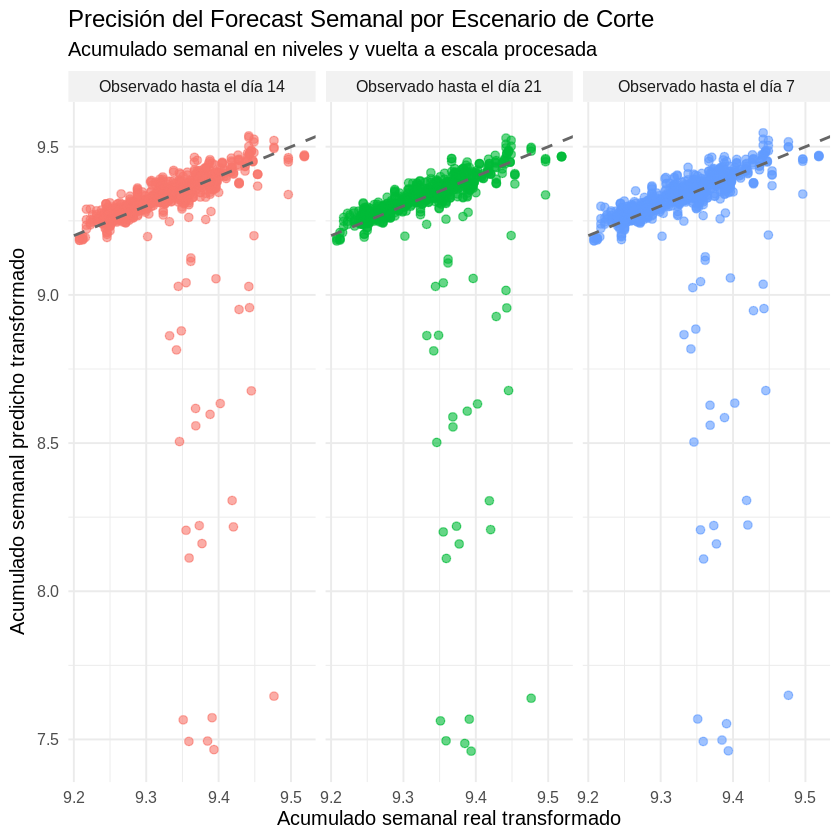

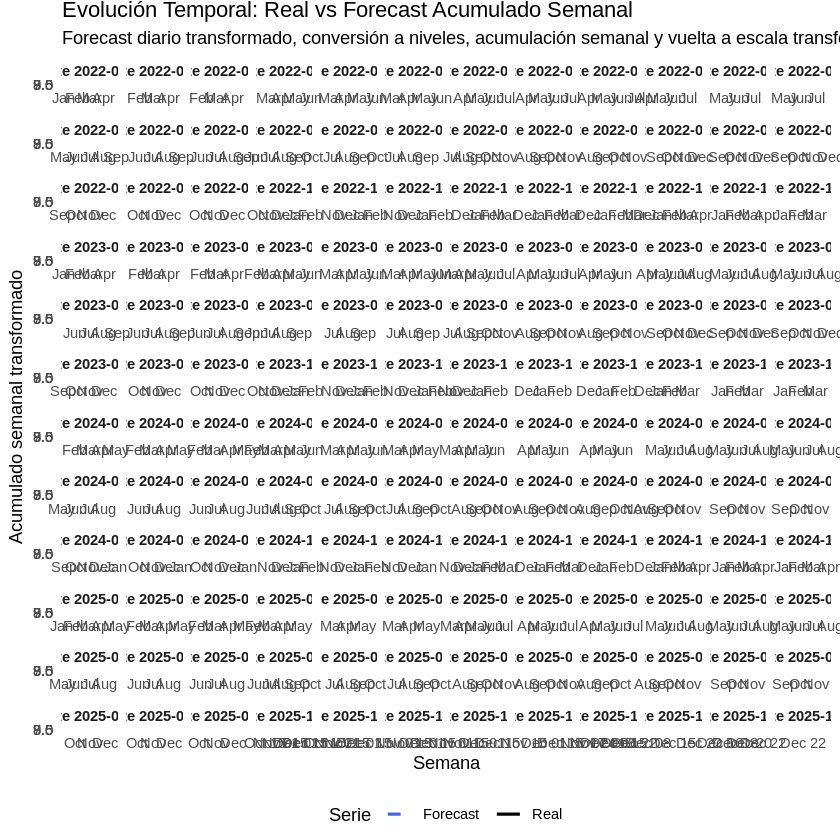

In [ ]:
# ============================================================
# EVALUACIÓN SEMANAL: forecast log -> niveles -> acumulado -> log
# ============================================================

df_eval_semanal <- resultados_experimento$weekly_eval %>%
  filter(
    has_full_observed_period,
    is.finite(real_proc),
    is.finite(pred_proc)
  ) %>%
  mutate(Escenario = paste("Observado hasta el día", cutoff_day))

metricas_semanales_escenario <- df_eval_semanal %>%
  group_by(cutoff_day) %>%
  summarise(
    n_periodos = n(),
    ME_pp      = mean(error_pp, na.rm = TRUE),
    MAE_pp     = mean(abs_error_pp, na.rm = TRUE),
    MedAE_pp   = median(abs_error_pp, na.rm = TRUE),
    RMSE_pp    = sqrt(mean(error_pp^2, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(cutoff_day = paste("D?a de corte:", cutoff_day))

print("=== FORECAST ACCURACY SEMANAL: log(acumulado en niveles), pp aprox ===")
print(metricas_semanales_escenario)

# ============================================================
# GRAFICO 1: REAL VS FORECAST (DISPERSIÓN CON LÍNEA DE REFERENCIA)
# ============================================================

ggplot(df_eval_semanal, aes(x = real_proc, y = pred_proc)) +
  geom_point(aes(color = Escenario), alpha = 0.6, size = 2) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray40", linewidth = 0.8) +
  facet_wrap(~Escenario) +
  theme_minimal(base_size = 12) +
  labs(
    title = "Precisión del Forecast Semanal por Escenario de Corte",
    subtitle = "Acumulado semanal en niveles y vuelta a escala procesada",
    x = "Acumulado semanal real transformado",
    y = "Acumulado semanal predicho transformado"
  ) +
  theme(legend.position = "none", strip.background = element_rect(fill = "gray95", color = NA))

# ============================================================
# GRAFICO 2: SERIES TEMPORALES FACETADAS POR VENTANA DE CORTE
# ============================================================

ggplot(df_eval_semanal, aes(x = period_start)) +
  geom_line(aes(y = real_proc, color = "Real"), linewidth = 0.9) +
  geom_line(aes(y = pred_proc, color = "Forecast"), linetype = "dashed", linewidth = 0.9) +
  facet_wrap(~id_ventana, scales = "free_x") +
  theme_minimal(base_size = 11) +
  scale_color_manual(values = c("Real" = "black", "Forecast" = "royalblue")) +
  labs(
    title = "Evolución Temporal: Real vs Forecast Acumulado Semanal",
    subtitle = "Forecast diario transformado, conversión a niveles, acumulación semanal y vuelta a escala transformada",
    x = "Semana",
    y = "Acumulado semanal transformado",
    color = "Serie"
  ) +
  theme(
    legend.position = "bottom",
    strip.text = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

[1] "=== FORECAST ACCURACY MENSUAL: log(acumulado en niveles), pp aprox ==="
# A tibble: 3 × 6
  cutoff_day       n_periodos ME_pp MAE_pp MedAE_pp RMSE_pp
  <chr>                 <int> <dbl>  <dbl>    <dbl>   <dbl>
1 Día de corte: 7         182 0.925   1.78    1.22     2.43
2 Día de corte: 14        182 0.856   1.64    1.10     2.29
3 Día de corte: 21        182 0.556   1.35    0.866    1.91
[1] "=== PRIMERAS FILAS MENSUALES EVALUADAS ==="


,id_ventana,cutoff_day,period_start,period_end,observed_partial_level,forecast_future_level,real_level,pred_level,real_proc,pred_proc,error_pp
,<chr>,<int>,<date>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Corte 2022-01-07,7,2022-01-01,2022-01-31,11258.41,35177.38,47022.93,46435.78,10.75839,10.74583,-1.2565139
2,Corte 2022-01-07,7,2022-02-01,2022-02-28,0.00,44295.26,45109.97,44295.26,10.71686,10.69863,-1.8225701
3,Corte 2022-01-07,7,2022-03-01,2022-03-31,0.00,48725.18,47552.43,48725.18,10.76959,10.79395,2.4363035
4,Corte 2022-01-07,7,2022-04-01,2022-04-30,0.00,48019.67,47574.76,48019.67,10.77006,10.77937,0.9308252
5,Corte 2022-01-14,14,2022-01-01,2022-01-31,21718.08,24579.76,47022.93,46297.84,10.75839,10.74285,-1.5540065
6,Corte 2022-01-14,14,2022-02-01,2022-02-28,0.00,44205.18,45109.97,44205.18,10.71686,10.69660,-2.0261282


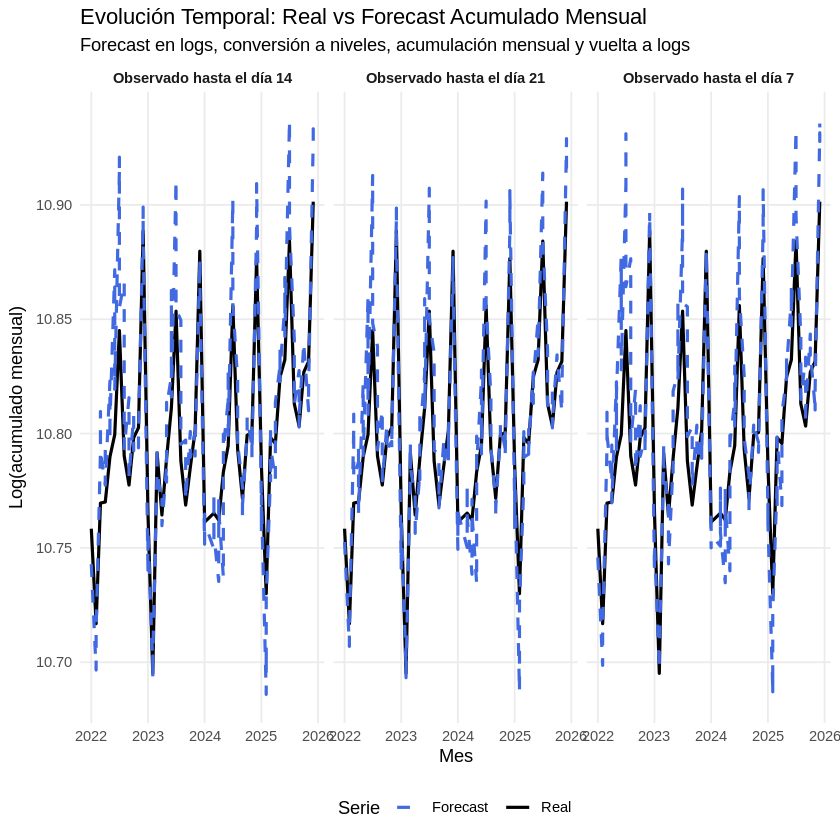

In [ ]:
# ============================================================
# EVALUACIÓN MENSUAL: forecast log -> niveles -> acumulado -> log
# ============================================================

df_eval_mensual <- resultados_experimento$monthly_eval %>%
  filter(has_full_observed_period, is.finite(real_proc), is.finite(pred_proc)) %>%
  mutate(Escenario = paste("Observado hasta el día", cutoff_day))

metricas_mensuales_escenario <- df_eval_mensual %>%
  group_by(cutoff_day) %>%
  summarise(
    n_periodos = n(),
    ME_pp      = mean(error_pp, na.rm = TRUE),
    MAE_pp     = mean(abs_error_pp, na.rm = TRUE),
    MedAE_pp   = median(abs_error_pp, na.rm = TRUE),
    RMSE_pp    = sqrt(mean(error_pp^2, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(cutoff_day = paste("Día de corte:", cutoff_day))

print("=== FORECAST ACCURACY MENSUAL: log(acumulado en niveles), pp aprox ===")
print(metricas_mensuales_escenario)

# Tabla de control: niveles acumulados y logs usados en m?tricas
print("=== PRIMERAS FILAS MENSUALES EVALUADAS ===")
head(df_eval_mensual %>%
  select(id_ventana, cutoff_day, period_start, period_end,
         observed_partial_level, forecast_future_level,
         real_level, pred_level, real_proc, pred_proc, error_pp))

# Gr?fico mensual por escenario de corte
ggplot(df_eval_mensual, aes(x = period_start)) +
  geom_line(aes(y = real_proc, color = "Real"), linewidth = 0.9) +
  geom_line(aes(y = pred_proc, color = "Forecast"), linetype = "dashed", linewidth = 0.9) +
  facet_wrap(~Escenario, scales = "free_x") +
  theme_minimal(base_size = 11) +
  scale_color_manual(values = c("Real" = "black", "Forecast" = "royalblue")) +
  labs(
    title = "Evolución Temporal: Real vs Forecast Acumulado Mensual",
    subtitle = "Forecast en logs, conversión a niveles, acumulación mensual y vuelta a logs",
    x = "Mes",
    y = "Log(acumulado mensual)",
    color = "Serie"
  ) +
  theme(
    legend.position = "bottom",
    strip.text = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )
